# Trabalho 05: Clusterização Temática e Deep Learning
**Disciplina**: Ciência de Dados e Machine Learning

---

## 1. Preparação do Ambiente
Instalação e importação das bibliotecas essenciais para Processamento de Linguagem Natural (NLP), geração de gráficos e Machine Learning. Também realizamos o download dos pacotes do `NLTK` e do modelo base do `spaCy` em português.

In [1]:
!pip install transformers torch scikit-learn pandas spacy nltk matplotlib seaborn
!python -m spacy download pt_core_news_lg

import nltk
nltk.download('stopwords')
nltk.download('punkt')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requ

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 2. Carregamento e Engenharia de Atributos
Nesta etapa, carregamos o dataset tabular e realizamos a união e limpeza inicial das features. A abordagem inclui:
- **Reforço de Título**: Concatenação duplicada do título para aumentar o peso vetorial do tema.
- **Remoção de Ruídos**: Filtragem baseada em heurísticas para excluir projetos curtos demais, cancelados ou de teor confidencial.

*Nota: Uma amostra de 500 registros é utilizada inicialmente. Remova a amostragem para a execução final.*

In [2]:
import pandas as pd
import unicodedata

caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv'
df = pd.read_csv(caminho_arquivo, encoding='latin-1', sep='\t')

df['titulo'] = df['Título_Público'].fillna('').astype(str).str.strip()
df['descricao'] = df['Descricao_pública'].fillna('').astype(str).str.strip()

df['texto_completo'] = df['titulo'] + ". " + df['titulo'] + ". " + df['descricao']
df = df.drop_duplicates(subset=['texto_completo']).copy()

def identificar_ruido(texto):
    texto_norm = unicodedata.normalize('NFKD', str(texto).lower()).encode('ASCII', 'ignore').decode('utf-8')
    qtd_palavras = len(texto_norm.split())
    
    curto_demais = qtd_palavras <= 4
    nao_divulgado = "confidencial" in texto_norm or "nao divulgado" in texto_norm
    cancelado = "cancelado" in texto_norm or "pendente definicao" in texto_norm
    
    return curto_demais or nao_divulgado or cancelado

df['is_ruido'] = df['texto_completo'].apply(identificar_ruido)
df_limpo = df[~df['is_ruido']].copy()

print(f"Total de registros após limpeza de ruídos: {len(df_limpo)}")

df_amostra = df_limpo.copy()

Total de registros após limpeza de ruídos: 2703


## 3. Limpeza Textual Estrita para EDA
Criação de uma coluna otimizada unicamente para contagens estatísticas, removendo caracteres especiais e *stopwords* genéricas do português, além de *stopwords* customizadas frequentes no domínio de projetos.

In [3]:
from nltk.corpus import stopwords
import re

stop_words_pt = set(stopwords.words('portuguese'))
stop_words_pt.update(['desenvolvimento', 'projeto', 'objetivo', 'estudo', 'uso', 'empresa', 'novo', 'nova'])

def limpar_texto_para_grafico(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõç\s]', ' ', texto)
    
    palavras = texto.split()
    palavras_limpas = [p for p in palavras if p not in stop_words_pt and len(p) > 2]
    
    return " ".join(palavras_limpas)

print("Limpando textos e removendo stopwords...")
df_amostra['texto_limpo'] = df_amostra['texto_completo'].apply(limpar_texto_para_grafico)
print("Textos limpos com sucesso!")

Limpando textos e removendo stopwords...
Textos limpos com sucesso!


## 4. Análise Exploratória de Dados (EDA)
Visualização das palavras mais relevantes do *corpus* semântico limpo, utilizando um `CountVectorizer`.

--- ANÁLISE EXPLORATÓRIA DE DADOS (EDA) ---

Tabela: Top 10 Termos mais frequentes no Dataset:


,Termo,Frequencia
10,sistema,1169
11,processo,740
1,produção,670
4,desenvolver,610
15,dados,525
13,solução,461
9,controle,437
17,plataforma,417
0,aplicação,416
14,sistemas,411


/tmp/ipykernel_23/3083702009.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_frequencia, x='Frequencia', y='Termo', palette='viridis')


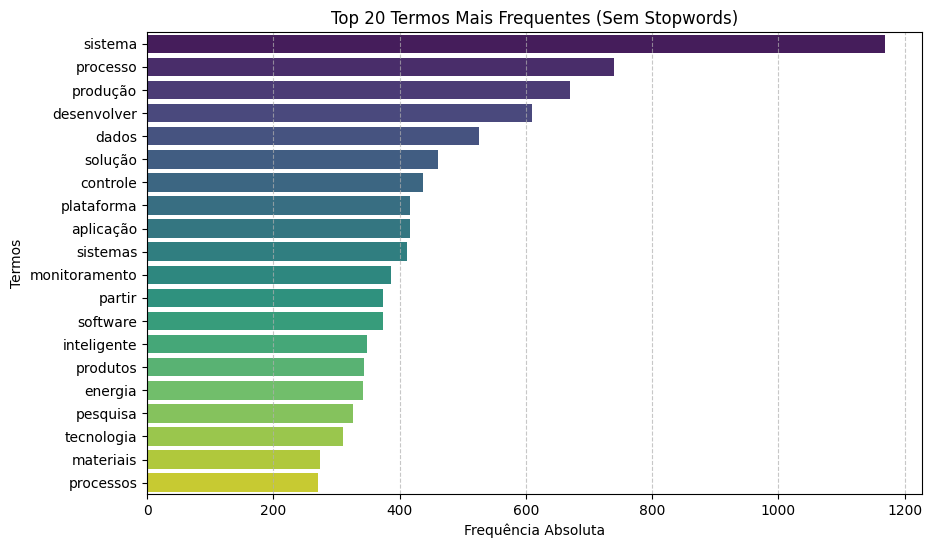

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

print("--- ANÁLISE EXPLORATÓRIA DE DADOS (EDA) ---\n")

vectorizer = CountVectorizer(max_features=20)
X_counts = vectorizer.fit_transform(df_amostra['texto_limpo'])

soma_palavras = X_counts.sum(axis=0)
frequencias = [(palavra, soma_palavras[0, idx]) for palavra, idx in vectorizer.vocabulary_.items()]
df_frequencia = pd.DataFrame(frequencias, columns=['Termo', 'Frequencia']).sort_values(by='Frequencia', ascending=False)

print("Tabela: Top 10 Termos mais frequentes no Dataset:")
display(df_frequencia.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_frequencia, x='Frequencia', y='Termo', palette='viridis')
plt.title('Top 20 Termos Mais Frequentes (Sem Stopwords)')
plt.xlabel('Frequência Absoluta')
plt.ylabel('Termos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 5. Extração Automática de Entidades (Weak Supervision)
Aplicação de um modelo estático (`pt_core_news_lg`) para extrair gabaritos de Entidades Nomeadas. Adicionamos uma heurística para isolar erros de predição clássicos da base (ex: *Brasil*).

In [5]:
import spacy

nlp_base = spacy.load("pt_core_news_lg")
dados_treino = []

for texto in df_amostra['texto_completo']:
    doc = nlp_base(texto)
    entidades = []
    
    for ent in doc.ents:
        label = ent.label_
        
        if ent.text.strip().lower() == 'brasil' and label != 'LOC':
            label = 'LOC'
            
        entidades.append((ent.start_char, ent.end_char, label))
    
    if entidades:
        dados_treino.append((texto, {"entities": entidades}))

print(f"Total de textos anotados para treino do novo NER: {len(dados_treino)}")

Total de textos anotados para treino do novo NER: 2134


## 6. Fine-Tuning do Modelo NER
Treinamento de um novo *pipeline* de Reconhecimento de Entidades Nomeadas (NER) vazio, alimentado com as predições supervisionadas da etapa anterior para estabilizar os aprendizados em 15 épocas.

In [6]:
import random
from spacy.training.example import Example

nlp_novo = spacy.blank("pt")
ner = nlp_novo.add_pipe("ner")

for _, anotacoes in dados_treino:
    for ent in anotacoes.get("entities"):
        ner.add_label(ent[2])

optimizer = nlp_novo.begin_training()
epocas = 25 

print("Iniciando treinamento do modelo NER customizado...")
for itn in range(epocas):
    random.shuffle(dados_treino)
    losses = {}
    
    for texto, anotacoes in dados_treino:
        doc = nlp_novo.make_doc(texto)
        example = Example.from_dict(doc, anotacoes)
        nlp_novo.update([example], sgd=optimizer, drop=0.3, losses=losses)
        
    print(f"Época {itn+1}/{epocas} concluída - Loss: {losses['ner']:.4f}")

Iniciando treinamento do modelo NER customizado...
Época 1/25 concluída - Loss: 12620.1582
Época 2/25 concluída - Loss: 10757.8311
Época 3/25 concluída - Loss: 9892.6172
Época 4/25 concluída - Loss: 8860.0791
Época 5/25 concluída - Loss: 8515.1367
Época 6/25 concluída - Loss: 8167.9443
Época 7/25 concluída - Loss: 7522.8345
Época 8/25 concluída - Loss: 7290.4844
Época 9/25 concluída - Loss: 6871.7998
Época 10/25 concluída - Loss: 6677.0186
Época 11/25 concluída - Loss: 6170.2495
Época 12/25 concluída - Loss: 6255.9146
Época 13/25 concluída - Loss: 6032.6172
Época 14/25 concluída - Loss: 5776.4346
Época 15/25 concluída - Loss: 5828.5044
Época 16/25 concluída - Loss: 5372.7344
Época 17/25 concluída - Loss: 5151.6489
Época 18/25 concluída - Loss: 5092.5200
Época 19/25 concluída - Loss: 5039.3296
Época 20/25 concluída - Loss: 4864.5693
Época 21/25 concluída - Loss: 4724.8916
Época 22/25 concluída - Loss: 4742.6064
Época 23/25 concluída - Loss: 4664.8813
Época 24/25 concluída - Loss: 4542.7

## 7. Geração de Vetores com BERTimbau
Utilização de modelos Transformer pré-treinados para gerar matrizes de Embeddings a partir da coluna de texto original. A inferência é direcionada via *tensors* do PyTorch (utilizando GPU, caso ativada).

In [7]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de processamento: {device}")

nome_modelo = 'neuralmind/bert-base-portuguese-cased'
tokenizer = AutoTokenizer.from_pretrained(nome_modelo)
modelo_bert = AutoModel.from_pretrained(nome_modelo).to(device)

def extrair_embeddings(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = modelo_bert(**inputs)
        
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embeddings.cpu().numpy()

print("Gerando representações vetoriais (Embeddings)...")
df_amostra['embeddings'] = df_amostra['texto_completo'].apply(extrair_embeddings)
matriz_embeddings = np.vstack(df_amostra['embeddings'].values)
print("Embeddings gerados!")

Dispositivo de processamento: cuda


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Gerando representações vetoriais (Embeddings)...
Embeddings gerados!


## 8. Clusterização e Geração da Tabela Resumo
Nesta etapa, utilizamos o algoritmo **K-Means** para agrupar os vetores semânticos gerados pelo BERTimbau em 20 clusters. 

Para automatizar a nomeação e análise de cada grupo:
1. Extraímos as palavras mais representativas via **TF-IDF**.
2. Contabilizamos as entidades NER mais frequentes.
3. Detectamos automaticamente o **Cluster Residual** (aquele com maior percentual de textos sem entidades reconhecidas), atribuindo a ele a nomenclatura de "Projetos técnico-operacionais gerais".

In [8]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import pandas as pd

num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
df_amostra['cluster'] = kmeans.fit_predict(matriz_embeddings)

print(f"Clusters gerados com sucesso! Analisando os {num_clusters} grupos...\n")

resumo = []

for cluster_id in range(num_clusters):
    df_cluster = df_amostra[df_amostra['cluster'] == cluster_id]
    qtd_textos = len(df_cluster)
    
    tfidf = TfidfVectorizer(max_features=4)
    try:
        tfidf.fit_transform(df_cluster['texto_limpo'])
        termos = ", ".join(tfidf.get_feature_names_out()).upper()
    except:
        termos = "N/A"
        
    labels_encontradas = []
    textos_sem_ner = 0
    
    for texto in df_cluster['texto_completo']:
        doc = nlp_novo(texto)
        if len(doc.ents) == 0:
            textos_sem_ner += 1
        else:
            labels_encontradas.extend([ent.label_ for ent in doc.ents])
            
    perc_sem_ner = (textos_sem_ner / qtd_textos) * 100 if qtd_textos > 0 else 0
    labels_principais = ", ".join([l[0] for l in Counter(labels_encontradas).most_common(3)])
    
    titulos = " | ".join(df_cluster['titulo'].head(2).values)
    
    resumo.append({
        "cluster": cluster_id,
        "quantidade_textos": qtd_textos,
        "percentual_sem_entidade_ner": perc_sem_ner,
        "termos_principais": termos,
        "labels_ner_principais": labels_principais,
        "titulos_representativos": titulos
    })

df_resumo = pd.DataFrame(resumo)

cluster_residual = int(
    df_resumo.sort_values(by=["percentual_sem_entidade_ner", "quantidade_textos"], ascending=[False, False])
    .iloc[0]["cluster"]
)
print(f"🔍 Cluster Residual detectado automaticamente: Cluster {cluster_residual}\n")

def nomear_cluster(row):
    if row['cluster'] == cluster_residual:
        return "Projetos técnico-operacionais gerais (Residual)"
    return row['termos_principais'] 

df_resumo['nome_cluster'] = df_resumo.apply(nomear_cluster, axis=1)

df_resumo_final = df_resumo[[
    "cluster", "nome_cluster", "quantidade_textos", 
    "termos_principais", "labels_ner_principais", "titulos_representativos"
]]

display(df_resumo_final)

Clusters gerados com sucesso! Analisando os 20 grupos...

🔍 Cluster Residual detectado automaticamente: Cluster 11



,cluster,nome_cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,"AVALIAÇÃO, SISTEMA, TRATAMENTO, UTILIZANDO",83,"AVALIAÇÃO, SISTEMA, TRATAMENTO, UTILIZANDO","MISC, ORG, PER",Sistema especialista de avaliação de pacientes...
1,1,"DESENVOLVER, EQUIPAMENTO, PROTÓTIPO, SISTEMA",95,"DESENVOLVER, EQUIPAMENTO, PROTÓTIPO, SISTEMA","MISC, ORG, LOC",Dr. Manhattan | Controlador Eletrônico - Fase ...
2,2,"DESENVOLVER, MONITORAMENTO, PROTÓTIPO, SISTEMA",224,"DESENVOLVER, MONITORAMENTO, PROTÓTIPO, SISTEMA","MISC, ORG, LOC",Siemens-Energy | Identificação eletrônica em s...
3,3,"ALTA, AMBIENTAIS, ELETRÔNICA, FLEXÍVEIS",17,"ALTA, AMBIENTAIS, ELETRÔNICA, FLEXÍVEIS","MISC, ORG, LOC",PROTÓTIPO NACIONAL DE BATERIA LÍTIO DE BAIXA T...
4,4,"INTELIGÊNCIA, PLATAFORMA, SOFTWARE, SOLUÇÃO",178,"INTELIGÊNCIA, PLATAFORMA, SOFTWARE, SOLUÇÃO","MISC, ORG, LOC",HUAWEI - PV generation with optimal BESS based...
5,5,"ENERGIA, INTELIGENTE, PROCESSO, SISTEMA",152,"ENERGIA, INTELIGENTE, PROCESSO, SISTEMA","MISC, ORG, LOC",DESENVOLVIMENTO DE HARDWARE DE AQUISIÇÃO PARA ...
6,6,"BASE, CONTROLE, PRAGAS, PRODUÇÃO",127,"BASE, CONTROLE, PRAGAS, PRODUÇÃO","MISC, LOC, PER",Uso de fungos entomopatogênicos no controle de...
7,7,"APLICAÇÃO, DESENVOLVER, PRIMA, PROCESSO",126,"APLICAÇÃO, DESENVOLVER, PRIMA, PROCESSO","LOC, MISC, ORG",Biocombustível Marítimo | Biofilmes para subst...
8,8,"COMUNICAÇÃO, IOT, MÓDULO, SISTEMA",151,"COMUNICAÇÃO, IOT, MÓDULO, SISTEMA","MISC, ORG, LOC",Datacenter Analytics | Driver para coleta de d...
9,9,"ANÁLISE, ELETRÔNICA, PRODUÇÃO, SISTEMA",55,"ANÁLISE, ELETRÔNICA, PRODUÇÃO, SISTEMA","MISC, ORG, LOC",Projeto de Desenvolvimento da versão Alfa da E...


## 9. Visualização de Clusters: PCA
Projeção linear dos embeddings de 768 dimensões para um espaço 2D. Esta visualização permite observar a distribuição global dos projetos e a densidade dos agrupamentos temáticos.

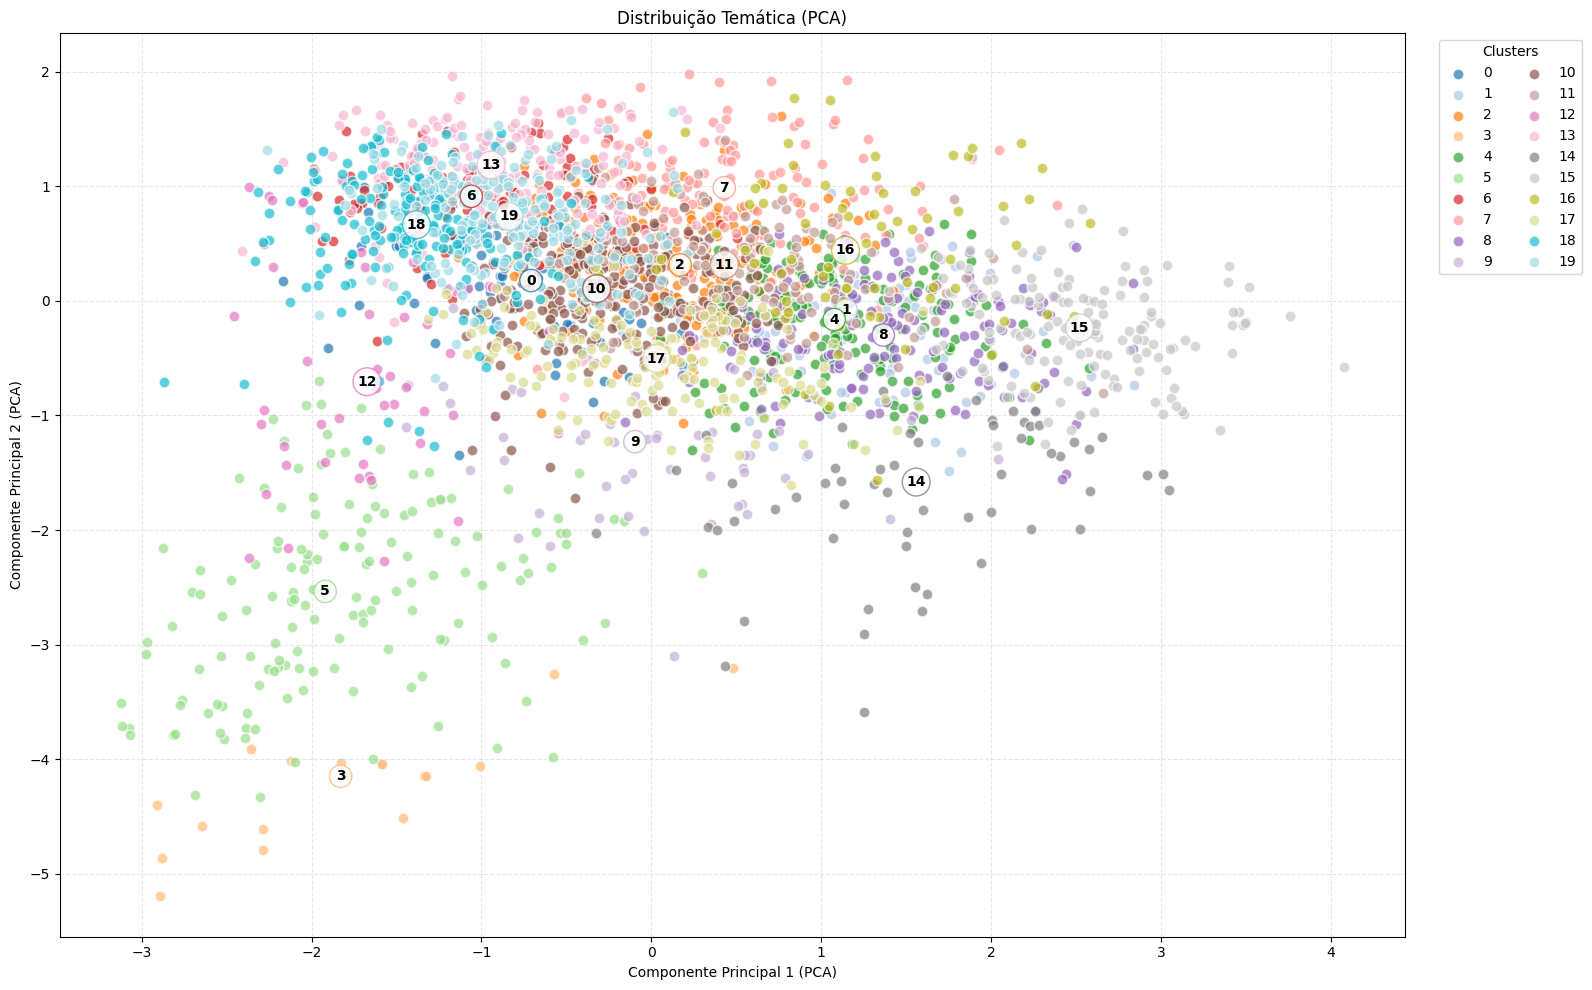

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

nomes_clusters = {row['cluster']: row['nome_cluster'] for _, row in df_resumo.iterrows()}

pca = PCA(n_components=2, random_state=42)
pontos_pca = pca.fit_transform(matriz_embeddings)

df_amostra['pca_1'] = pontos_pca[:, 0]
df_amostra['pca_2'] = pontos_pca[:, 1]

plt.figure(figsize=(16, 10))
clusters_ordenados = sorted(df_amostra["cluster"].unique())
cores = plt.cm.tab20.colors 

for i, cluster_id in enumerate(clusters_ordenados):
    df_cluster = df_amostra[df_amostra["cluster"] == cluster_id]
    cor_atual = cores[i % len(cores)]
    
    plt.scatter(df_cluster["pca_1"], df_cluster["pca_2"], label=f"{cluster_id}", alpha=0.7, s=60, edgecolors='w', color=cor_atual)
    
    x_mediano = df_cluster["pca_1"].median()
    y_mediano = df_cluster["pca_2"].median()
    
    plt.text(x_mediano, y_mediano, f"{cluster_id}", fontsize=10, fontweight='bold', ha="center", va="center", bbox=dict(boxstyle="circle", fc="white", ec=cor_atual, alpha=0.8))

plt.xlabel("Componente Principal 1 (PCA)")
plt.ylabel("Componente Principal 2 (PCA)")
plt.title("Distribuição Temática (PCA)")
plt.legend(title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Visualização de Clusters: t-SNE
Projeção não-linear utilizando **t-SNE**. Este algoritmo é otimizado para criar separações mais nítidas entre os grupos, permitindo a identificação de "ilhas" de conhecimento dentro do dataset.

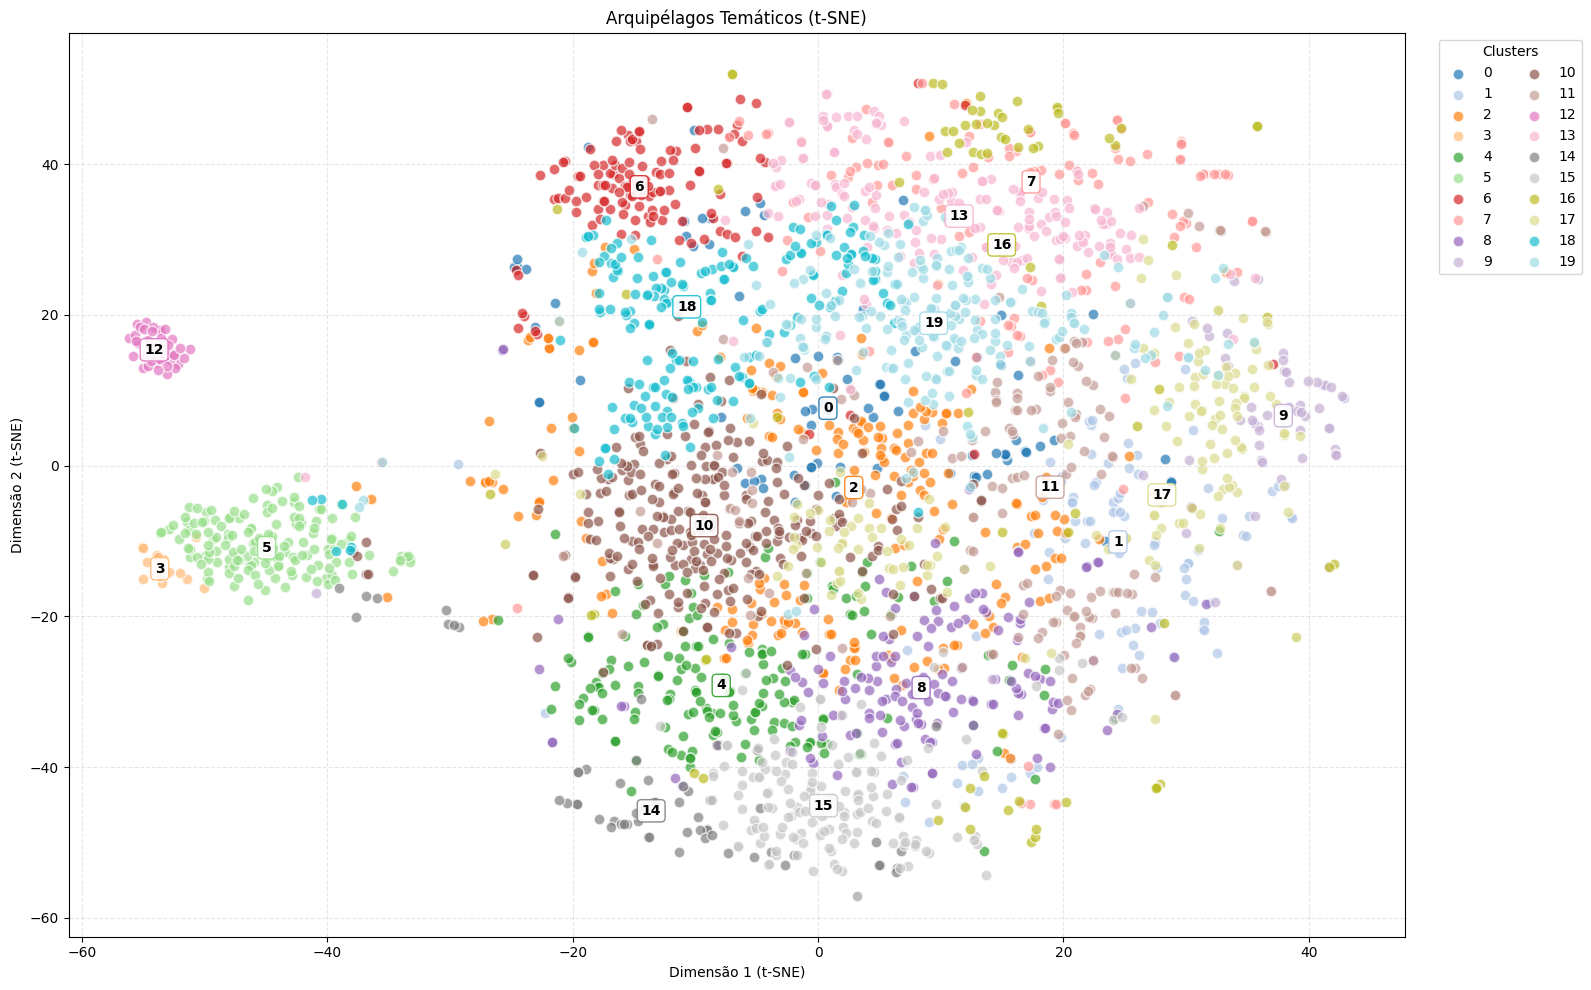

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto', early_exaggeration=12)
pontos_tsne = tsne.fit_transform(matriz_embeddings)

df_amostra['tsne_1'] = pontos_tsne[:, 0]
df_amostra['tsne_2'] = pontos_tsne[:, 1]

plt.figure(figsize=(16, 10))

for i, cluster_id in enumerate(clusters_ordenados):
    df_cluster = df_amostra[df_amostra["cluster"] == cluster_id]
    cor_atual = cores[i % len(cores)]
    
    plt.scatter(df_cluster["tsne_1"], df_cluster["tsne_2"], label=f"{cluster_id}", alpha=0.7, s=60, edgecolors='w', color=cor_atual)
    
    x_mediano = df_cluster["tsne_1"].median()
    y_mediano = df_cluster["tsne_2"].median()
    
    plt.text(x_mediano, y_mediano, f"{cluster_id}", fontsize=10, fontweight='bold', ha="center", va="center", bbox=dict(boxstyle="round", fc="white", ec=cor_atual, alpha=0.9))

plt.xlabel("Dimensão 1 (t-SNE)")
plt.ylabel("Dimensão 2 (t-SNE)")
plt.title("Arquipélagos Temáticos (t-SNE)")
plt.legend(title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Raio-X dos Assuntos (Interpretação Detalhada)
Análise aprofundada dos agrupamentos. Este bloco itera sobre os clusters gerados, exibindo as entidades mais citadas e exemplos práticos de títulos presentes em cada "nicho" temático.

In [11]:
print("--- IDENTIFICAÇÃO DETALHADA DOS ASSUNTOS POR CLUSTER ---\n")

for cluster_id in sorted(df_amostra['cluster'].unique()):
    print(f"\n{'='*70}")
    print(f"🌟 CLUSTER {cluster_id} (Total de projetos: {len(df_amostra[df_amostra['cluster'] == cluster_id])})")
    print(f"{'='*70}")
    
    dados_do_cluster = df_amostra[df_amostra['cluster'] == cluster_id]
    
    tfidf = TfidfVectorizer(max_features=7)
    try:
        tfidf.fit_transform(dados_do_cluster['texto_limpo'])
        termos_principais = tfidf.get_feature_names_out()
        print(f"🔑 ASSUNTOS PRINCIPAIS: {', '.join(termos_principais).upper()}")
    except ValueError:
        print(f"🔑 ASSUNTOS PRINCIPAIS: N/A")

    todas_entidades = []
    for texto in dados_do_cluster['texto_completo'].head(30):
        doc = nlp_novo(texto)
        todas_entidades.extend([ent.text.strip() for ent in doc.ents if len(ent.text.strip()) > 2])
    
    if todas_entidades:
        entidades_comuns = [ent[0] for ent in Counter(todas_entidades).most_common(5)]
        print(f"🏛️ ENTIDADES MAIS CITADAS: {', '.join(entidades_comuns)}")
        
    print("\n📌 Exemplos de Projetos neste grupo:")
    for titulo in dados_do_cluster['titulo'].head(3):
        print(f"   - {titulo}")

--- IDENTIFICAÇÃO DETALHADA DOS ASSUNTOS POR CLUSTER ---


🌟 CLUSTER 0 (Total de projetos: 83)
🔑 ASSUNTOS PRINCIPAIS: AVALIAÇÃO, DADOS, DETECÇÃO, MONITORAMENTO, SISTEMA, TRATAMENTO, UTILIZANDO
🏛️ ENTIDADES MAIS CITADAS: AUVs, Parte SENAI CIMATEC, Doença de Chagas, Coronavírus, iPhone

📌 Exemplos de Projetos neste grupo:
   - Sistema especialista de avaliação de pacientes para tratamento de tomografia computadorizada
   - Estudo e desenvolvimento de biossensores para detecção de cianotoxinas em amostras de água.
   - Estudo e desenvolvimento de sensores elétricos e eletroquímicos para a previsão da qualidade da carne bovina

🌟 CLUSTER 1 (Total de projetos: 95)
🔑 ASSUNTOS PRINCIPAIS: CONTROLE, DESENVOLVER, DISPOSITIVO, EQUIPAMENTO, PROTÓTIPO, SENSOR, SISTEMA
🏛️ ENTIDADES MAIS CITADAS: Dr. Manhattan, NanoBox para Transformadores, Fechadura Conectada, Potência - Controle de Motor Elétrico, Automação de Operações

📌 Exemplos de Projetos neste grupo:
   - Dr. Manhattan
   - Controlador Eletr

## 12. Inferência e Validação do Modelo NER
Por fim, realizamos a inferência do modelo treinado em amostras reais do dataset para validar a precisão da extração de entidades técnicas e organizacionais.

In [12]:
print("--- VALIDAÇÃO DE EXTRAÇÃO DE ENTIDADES ---\n")

amostras_teste = df_amostra['texto_completo'].head(5).values

for texto in amostras_teste:
    doc = nlp_novo(texto)
    entidades_encontradas = [(ent.text, ent.label_) for ent in doc.ents]
    texto_exibicao = texto[:400] + "..." if len(texto) > 400 else texto
        
    print(f"TEXTO: {texto_exibicao}")
    print(f"ENTIDADES: {entidades_encontradas}")
    print("-" * 100)

--- VALIDAÇÃO DE EXTRAÇÃO DE ENTIDADES ---

TEXTO: Açúcar de frutas e aplicação em bolos como substituto da sacarose. Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contri...
ENTIDADES: [('Brasil', 'LOC'), ('Objetivos de Desenvolvimento Sustentável', 'ORG'), ('ODS', 'ORG'), ('Organização das Nações Unidas', 'ORG'), ('ONU', 'ORG'), ('Objetivo 12', 'MISC')]
----------------------------------------------------------------------------------------------------
TEXTO: Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos 